In [1]:

import torch
import torch.nn as nn
import time

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Selected device:", device)


PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
GPU count: 1
Selected device: cuda


In [2]:

# Reproducible synthetic server dataset
torch.manual_seed(42)

N = 10000

temperature = torch.normal(75, 10, (N, 1))
power = torch.normal(700, 150, (N, 1))
errors = torch.poisson(torch.full((N, 1), 2.0))
fan_speed = torch.normal(5000, 1000, (N, 1))
age = torch.rand(N, 1) * 5

X_raw = torch.cat(
    [temperature, power, errors, fan_speed, age],
    dim=1
)

# Generate synthetic failure labels
risk = (
    0.06 * (temperature - 75)
    + 0.002 * (power - 700)
    + 0.45 * (errors - 2)
    + 0.00025 * (fan_speed - 5000)
    + 0.35 * (age - 2.5)
)

y = torch.bernoulli(torch.sigmoid(risk))

# Train/test split
indices = torch.randperm(N)
train_idx = indices[:8000]
test_idx = indices[8000:]

# Normalize using training data statistics
feature_mean = X_raw[train_idx].mean(dim=0)
feature_std = X_raw[train_idx].std(dim=0).clamp_min(1e-6)

X = (X_raw - feature_mean) / feature_std

X_train = X[train_idx].to(device)
y_train = y[train_idx].to(device)
X_test = X[test_idx].to(device)
y_test = y[test_idx].to(device)

# Build and train model
model = nn.Linear(5, 1).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(101):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss {loss.item():.4f}")

# Evaluate
model.eval()

with torch.no_grad():
    probabilities = torch.sigmoid(model(X_test))
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == y_test).float().mean()

print("\nTraining complete")
print("Model device:", model.weight.device)
print("Test shape:", X_test.shape)
print("Test accuracy:", round(accuracy.item(), 4))


Epoch   0 | Loss 0.7718
Epoch  20 | Loss 0.6586
Epoch  40 | Loss 0.6148
Epoch  60 | Loss 0.5968
Epoch  80 | Loss 0.5889
Epoch 100 | Loss 0.5850

Training complete
Model device: cuda:0
Test shape: torch.Size([2000, 5])
Test accuracy: 0.6765


In [3]:

import time

# Select one server from the test set
x_one = X_test[0:1]

# Warm up GPU
with torch.inference_mode():
    for _ in range(20):
        model(x_one)

torch.cuda.synchronize()

# Measure inference over repeated requests
latencies_ms = []

with torch.inference_mode():
    for _ in range(100):
        torch.cuda.synchronize()
        start = time.perf_counter()

        logit = model(x_one)

        torch.cuda.synchronize()
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000)

probability = torch.sigmoid(logit).item()

print("Input shape:", x_one.shape)
print("Input device:", x_one.device)
print("Predicted failure probability:", round(probability, 4))
print("Average inference latency:",
      round(sum(latencies_ms) / len(latencies_ms), 4), "ms")
print("Minimum inference latency:",
      round(min(latencies_ms), 4), "ms")
print("Maximum inference latency:",
      round(max(latencies_ms), 4), "ms")


Input shape: torch.Size([1, 5])
Input device: cuda:0
Predicted failure probability: 0.4676
Average inference latency: 0.054 ms
Minimum inference latency: 0.0453 ms
Maximum inference latency: 0.1533 ms


In [4]:

import time

batch_sizes = [1, 10, 100, 1000, 2000]
results = []

model.eval()

with torch.inference_mode():
    for batch_size in batch_sizes:
        x_batch = X_test[:batch_size]

        # Warm up
        for _ in range(20):
            model(x_batch)

        torch.cuda.synchronize()
        latencies = []

        # Measure 100 repeated inference calls
        for _ in range(100):
            torch.cuda.synchronize()
            start = time.perf_counter()

            logits = model(x_batch)

            torch.cuda.synchronize()
            elapsed = time.perf_counter() - start
            latencies.append(elapsed)

        avg_latency = sum(latencies) / len(latencies)
        throughput = batch_size / avg_latency

        results.append((batch_size, avg_latency * 1000, throughput))

        print(
            f"Batch: {batch_size:>4} | "
            f"Latency: {avg_latency * 1000:.4f} ms | "
            f"Throughput: {throughput:,.0f} predictions/sec"
        )


Batch:    1 | Latency: 0.0713 ms | Throughput: 14,027 predictions/sec
Batch:   10 | Latency: 0.0491 ms | Throughput: 203,700 predictions/sec
Batch:  100 | Latency: 0.0710 ms | Throughput: 1,407,589 predictions/sec
Batch: 1000 | Latency: 0.0569 ms | Throughput: 17,583,583 predictions/sec
Batch: 2000 | Latency: 0.0506 ms | Throughput: 39,498,066 predictions/sec


In [5]:

import numpy as np
import time

batch_size = 100
x_batch = X_test[:batch_size]

latencies_ms = []

model.eval()

with torch.inference_mode():

    # Warm up
    for _ in range(50):
        model(x_batch)

    torch.cuda.synchronize()

    # Measure 500 inference calls
    for _ in range(500):

        torch.cuda.synchronize()
        start = time.perf_counter()

        logits = model(x_batch)

        torch.cuda.synchronize()
        end = time.perf_counter()

        latencies_ms.append((end - start) * 1000)

print("Batch size:", batch_size)
print("Average latency:", round(np.mean(latencies_ms), 4), "ms")
print("p50 latency:", round(np.percentile(latencies_ms, 50), 4), "ms")
print("p95 latency:", round(np.percentile(latencies_ms, 95), 4), "ms")
print("p99 latency:", round(np.percentile(latencies_ms, 99), 4), "ms")


Batch size: 100
Average latency: 0.0575 ms
p50 latency: 0.0506 ms
p95 latency: 0.0896 ms
p99 latency: 0.1272 ms


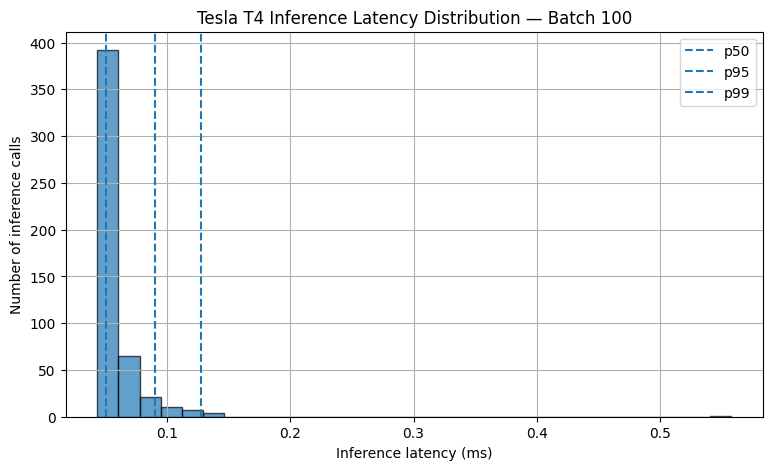

In [6]:

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 5))

plt.hist(latencies_ms, bins=30, edgecolor="black", alpha=0.7)

plt.axvline(
    np.percentile(latencies_ms, 50),
    linestyle="--",
    label="p50"
)

plt.axvline(
    np.percentile(latencies_ms, 95),
    linestyle="--",
    label="p95"
)

plt.axvline(
    np.percentile(latencies_ms, 99),
    linestyle="--",
    label="p99"
)

plt.xlabel("Inference latency (ms)")
plt.ylabel("Number of inference calls")
plt.title("Tesla T4 Inference Latency Distribution — Batch 100")

plt.legend()
plt.grid(True)
plt.show()


In [7]:

import copy
import time
import numpy as np

# Same trained model and weights on both devices
gpu_model = model.eval()
cpu_model = copy.deepcopy(model).to("cpu").eval()

batch_sizes_compare = [1, 100, 2000]
comparison_results = []

def measure_inference(model_to_test, inputs, use_cuda, repeats=300):
    times = []

    with torch.inference_mode():
        for _ in range(30):
            model_to_test(inputs)

        if use_cuda:
            torch.cuda.synchronize()

        for _ in range(repeats):
            if use_cuda:
                torch.cuda.synchronize()

            start = time.perf_counter()
            output = model_to_test(inputs)

            if use_cuda:
                torch.cuda.synchronize()

            times.append((time.perf_counter() - start) * 1000)

    return np.median(times)

for batch_size in batch_sizes_compare:
    x_gpu = X_test[:batch_size]
    x_cpu = x_gpu.cpu()

    cpu_ms = measure_inference(cpu_model, x_cpu, False)
    gpu_ms = measure_inference(gpu_model, x_gpu, True)

    comparison_results.append((batch_size, cpu_ms, gpu_ms))

    print(
        f"Batch {batch_size:>4} | "
        f"CPU p50: {cpu_ms:.4f} ms | "
        f"GPU p50: {gpu_ms:.4f} ms | "
        f"CPU/GPU: {cpu_ms/gpu_ms:.2f}x"
    )


Batch    1 | CPU p50: 0.0094 ms | GPU p50: 0.0561 ms | CPU/GPU: 0.17x
Batch  100 | CPU p50: 0.0117 ms | GPU p50: 0.0547 ms | CPU/GPU: 0.21x
Batch 2000 | CPU p50: 0.0221 ms | GPU p50: 0.0502 ms | CPU/GPU: 0.44x


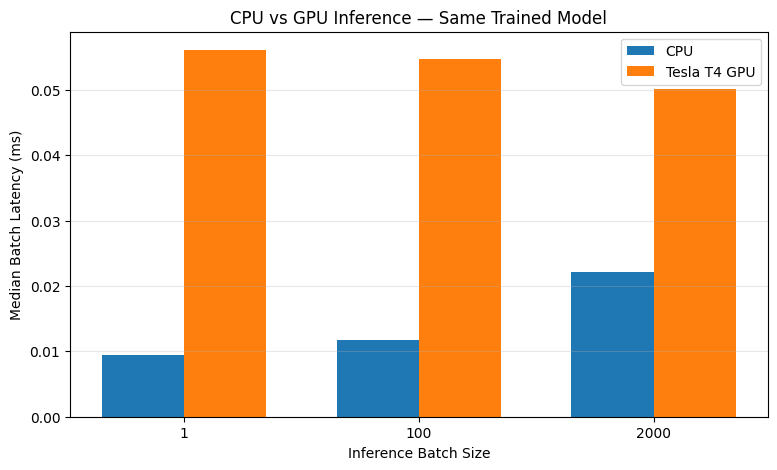

In [8]:

import matplotlib.pyplot as plt
import numpy as np

batch_sizes = [r[0] for r in comparison_results]
cpu_times = [r[1] for r in comparison_results]
gpu_times = [r[2] for r in comparison_results]

positions = np.arange(len(batch_sizes))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(positions - width/2, cpu_times, width, label="CPU")
plt.bar(positions + width/2, gpu_times, width, label="Tesla T4 GPU")

plt.xticks(positions, batch_sizes)
plt.xlabel("Inference Batch Size")
plt.ylabel("Median Batch Latency (ms)")
plt.title("CPU vs GPU Inference — Same Trained Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


In [9]:

print("=== COLAB 4: INFERENCE PERFORMANCE ===")

print("\nModel:")
print("Architecture: Linear(5, 1)")
print("Test accuracy: 67.65%")
print("GPU: Tesla T4")

print("\nLatency distribution — Batch 100:")
print(f"Average: {np.mean(latencies_ms):.4f} ms")
print(f"p50: {np.percentile(latencies_ms, 50):.4f} ms")
print(f"p95: {np.percentile(latencies_ms, 95):.4f} ms")
print(f"p99: {np.percentile(latencies_ms, 99):.4f} ms")

print("\nCPU vs GPU inference:")
for batch, cpu_ms, gpu_ms in comparison_results:
    print(
        f"Batch {batch}: "
        f"CPU={cpu_ms:.4f} ms, "
        f"GPU={gpu_ms:.4f} ms, "
        f"CPU speedup={gpu_ms/cpu_ms:.2f}x"
    )

print("\nKey findings:")
print("1. Inference uses a forward pass without backpropagation.")
print("2. Batching can increase prediction throughput.")
print("3. p95 and p99 reveal tail latency.")
print("4. CPU outperformed GPU for this small model.")
print("5. Hardware selection must be workload-driven.")


=== COLAB 4: INFERENCE PERFORMANCE ===

Model:
Architecture: Linear(5, 1)
Test accuracy: 67.65%
GPU: Tesla T4

Latency distribution — Batch 100:
Average: 0.0575 ms
p50: 0.0506 ms
p95: 0.0896 ms
p99: 0.1272 ms

CPU vs GPU inference:
Batch 1: CPU=0.0094 ms, GPU=0.0561 ms, CPU speedup=5.97x
Batch 100: CPU=0.0117 ms, GPU=0.0547 ms, CPU speedup=4.68x
Batch 2000: CPU=0.0221 ms, GPU=0.0502 ms, CPU speedup=2.27x

Key findings:
1. Inference uses a forward pass without backpropagation.
2. Batching can increase prediction throughput.
3. p95 and p99 reveal tail latency.
4. CPU outperformed GPU for this small model.
5. Hardware selection must be workload-driven.


In [10]:

# Save trained model and normalization parameters

checkpoint = {
    "model_state_dict": model.cpu().state_dict(),
    "feature_mean": feature_mean.cpu(),
    "feature_std": feature_std.cpu(),
    "input_features": 5,
    "model_type": "LinearBinaryClassifier"
}

torch.save(checkpoint, "server_failure_model.pth")

print("Model checkpoint saved successfully")
print("File: server_failure_model.pth")
print("Features:", checkpoint["input_features"])


Model checkpoint saved successfully
File: server_failure_model.pth
Features: 5
